# Micro Facial Expression

In [ ]:
# train_r3d_r3d18.py
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# =========================
# CONFIG - change as needed

BASE_PATH = r"D:\micro_facial_expression"
CONFIG = {
    "batch_size": 8,        # reduce if OOM
    "epochs": 20,
    "lr": 1e-4,
    "num_frames": 16,       # temporal length per sample (16 or 32)
    "img_size": 112,
    "num_workers": 0,       # windows-safe
    "pin_memory": False,    # set True if you want and it's supported
    "seed": 42,
    "freeze_at": None       # e.g. "layer1" to freeze early layers; None -> train all
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# =========================
# Utilities: label mapping & casme folder helper (your logic preserved)
# =========================
def map_emotion_to_class(emotion):
    emotion = str(emotion).strip().lower()
    if "fear" in emotion:
        return "Fear"
    elif "sad" in emotion:
        return "Sadness"
    elif "anger" in emotion:
        return "Anger"
    elif "disgust" in emotion:
        return "Disgust"
    elif any(e in emotion for e in ["happy", "happiness", "happyiness", "contempt"]):
        return "Happiness"
    elif "surprise" in emotion:
        return "Surprise"
    else:
        return "Others"

def find_casme3_folder(frames_root, sub, seq, onset=None, apex=None):
    if not os.path.exists(frames_root):
        return None
    prefix = f"{sub}_{seq}".replace("__", "_")
    candidates = [d for d in os.listdir(frames_root) if d.startswith(prefix) and os.path.isdir(os.path.join(frames_root, d))]
    if not candidates:
        return None
    onset_s = str(int(onset)) if onset not in (None, '', 'nan', np.nan) else None
    apex_s  = str(int(apex))  if apex  not in (None, '', 'nan', np.nan) else None
    for cand in candidates:
        try:
            suffix = cand.split('_')[-1]
            if onset_s and suffix == onset_s:
                return cand
            if apex_s and suffix == apex_s:
                return cand
        except:
            pass
    if onset_s:
        try:
            onset_val = int(onset_s)
            best, best_diff = None, None
            for cand in candidates:
                try:
                    suf = cand.split('_')[-1]
                    val = int(suf)
                    diff = abs(val - onset_val)
                    if best is None or diff < best_diff:
                        best = cand
                        best_diff = diff
                except:
                    pass
            if best:
                return best
        except:
            pass
    return candidates[0]

# =========================
# Sequence loader: returns DataFrame of sequences (one row per sequence folder)
# columns: path,label,onset,apex,offset,dataset
# =========================
def load_sequences(base_path):
    sequences = []
    # CASME2
    try:
        casme2_csv = os.path.join(base_path, "CASME2", "CASME2_Labelling.csv")
        if not os.path.exists(casme2_csv):
            casme2_csv = os.path.join(base_path, "CASME2", "CASME2", "CASME2_Labelling.csv")
        if os.path.exists(casme2_csv):
            df2 = pd.read_csv(casme2_csv)
            for _, row in df2.iterrows():
                subj = str(row['Subject']).strip()
                folder = str(row['Filename']).strip()
                label = map_emotion_to_class(row.get('Estimated Emotion', row.get('EstimatedEmotion','others')))
                path_options = [
                    os.path.join(base_path,"CASME2","CASME2","Extracts","cropped","cropped",subj,folder),
                    os.path.join(base_path,"CASME2","Extracts","cropped","cropped",subj,folder),
                    os.path.join(base_path,"CASME2",subj,folder)
                ]
                for p in path_options:
                    if os.path.exists(p):
                        imgs = [f for f in os.listdir(p) if f.lower().endswith(('.jpg','.jpeg','.png'))]
                        if imgs:
                            sequences.append({'path': p, 'label': label, 'onset': row.get('OnsetFrame'), 'apex': row.get('ApexFrame'), 'offset': row.get('OffsetFrame'), 'dataset':'CASME2'})
                        break
    except Exception as e:
        print("CASME2 skipped:", e)

    # CASMEII
    try:
        casmeii_xlsx = os.path.join(base_path, "CASMEII", "CASEME11_Labelling.xlsx")
        if not os.path.exists(casmeii_xlsx):
            casmeii_xlsx = os.path.join(base_path, "CASMEII", "CASMEII", "CASEME11_Labelling.xlsx")
        if os.path.exists(casmeii_xlsx):
            dfii = pd.read_excel(casmeii_xlsx)
            for _, row in dfii.iterrows():
                subj = f"sub{int(row['Subject']):02d}" if 'Subject' in row else str(row.get('Subject')).strip()
                folder = str(row['Filename']).strip()
                label = map_emotion_to_class(row.get('Estimated Emotion', row.get('EstimatedEmotion','others')))
                path_options = [
                    os.path.join(base_path,"CASMEII","CASMEII","Extracts","Cropped",subj,folder),
                    os.path.join(base_path,"CASMEII","Extracts","Cropped",subj,folder),
                ]
                for p in path_options:
                    if os.path.exists(p):
                        imgs = [f for f in os.listdir(p) if f.lower().endswith(('.jpg','.jpeg','.png'))]
                        if imgs:
                            sequences.append({'path': p, 'label': label, 'onset': row.get('OnsetFrame'), 'apex': row.get('ApexFrame'), 'offset': row.get('OffsetFrame'), 'dataset':'CASMEII'})
                        break
    except Exception as e:
        print("CASMEII skipped:", e)

    # CASME3 v1 and v2
    try:
        casme3_root = os.path.join(base_path, "CASME_3Full")
        v1_xlsx = os.path.join(casme3_root, "cas(me)3_part_A_ME_label_JpgIndex_v1.xls")
        v1_frames_root = os.path.join(casme3_root, "Part_A_ME_clip", "Part_A_ME_clip", "frame")
        if os.path.exists(v1_xlsx) and os.path.exists(v1_frames_root):
            df_v1 = pd.read_excel(v1_xlsx)
            for _, row in df_v1.iterrows():
                sub = str(row.get('Subject', row.get('sub',''))).strip()
                seq = str(row.get('Filename', row.get('seq',''))).strip()
                onset = row.get('Onset', row.get('onset', None))
                apex = row.get('Apex', row.get('apex', None))
                emotion = row.get('emotion', row.get('Emotion', row.get('Estimated Emotion','others')))
                label = map_emotion_to_class(emotion)
                folder = find_casme3_folder(v1_frames_root, sub, seq, onset=onset, apex=apex)
                if folder:
                    images_dir = os.path.join(v1_frames_root, folder, "images")
                    if not os.path.exists(images_dir):
                        images_dir = os.path.join(v1_frames_root, folder)
                    if os.path.exists(images_dir):
                        imgs = [f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
                        if imgs:
                            sequences.append({'path': images_dir, 'label': label, 'onset': onset, 'apex': apex, 'offset': row.get('Offset', None), 'dataset':'CASME3_v1'})
        v2_xlsx = os.path.join(casme3_root, "cas(me)3_part_A_MaE_label_JpgIndex_v2_emotion.xlsx")
        v2_frames_root = os.path.join(casme3_root, "Part_A_MaE_clip", "Part_A_MaE_clip", "frame")
        if os.path.exists(v2_xlsx) and os.path.exists(v2_frames_root):
            df_v2 = pd.read_excel(v2_xlsx)
            for _, row in df_v2.iterrows():
                sub = str(row.get('sub', row.get('Subject',''))).strip()
                seq = str(row.get('seq', row.get('Filename',''))).strip()
                onset = row.get('onset', None)
                apex = row.get('apex', None)
                emotion = row.get('emotion', row.get('Emotion','others'))
                label = map_emotion_to_class(emotion)
                folder = find_casme3_folder(v2_frames_root, sub, seq, onset=onset, apex=apex)
                if folder:
                    images_dir = os.path.join(v2_frames_root, folder, "images")
                    if not os.path.exists(images_dir):
                        images_dir = os.path.join(v2_frames_root, folder)
                    if os.path.exists(images_dir):
                        imgs = [f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
                        if imgs:
                            sequences.append({'path': images_dir, 'label': label, 'onset': onset, 'apex': apex, 'offset': row.get('offset', None), 'dataset':'CASME3_v2'})
    except Exception as e:
        print("CASME3 skipped:", e)

    # SAMM
    try:
        samm_label = os.path.join(base_path, "SAMM", "SAMM_Labelling.csv")
        if not os.path.exists(samm_label):
            samm_label = os.path.join(base_path, "SAMM", "SAMM", "SAMM_Labelling.csv")
        if os.path.exists(samm_label):
            df_samm = pd.read_csv(samm_label)
            for _, row in df_samm.iterrows():
                subj = str(row['Subject']).strip()
                folder = str(row['Filename']).strip()
                label = map_emotion_to_class(row.get('Estimated Emotion', row.get('EstimatedEmotion','others')))
                path = os.path.join(base_path, "SAMM", "SAMM", subj, folder)
                if not os.path.exists(path):
                    path = os.path.join(base_path, "SAMM", subj, folder)
                if os.path.exists(path):
                    imgs = [f for f in os.listdir(path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
                    if imgs:
                        sequences.append({'path': path, 'label': label, 'onset': None, 'apex': None, 'offset': None, 'dataset':'SAMM'})
    except Exception as e:
        print("SAMM skipped:", e)

    print("✅ Total sequences found:", len(sequences))
    return pd.DataFrame(sequences)

# =========================
# Sequence Dataset (returns frames tensor and label)
# frames shape returned: [T, C, H, W]
# =========================
class SequenceDataset(Dataset):
    def __init__(self, df_sequences, num_frames=16, img_size=112, transform=None):
        self.seqs = df_sequences.reset_index(drop=True)
        self.num_frames = num_frames
        self.img_size = img_size
        self.transform = transform

    def __len__(self):
        return len(self.seqs)

    def _list_frames(self, folder, onset=None, apex=None, offset=None):
        imgs = sorted([f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        img_paths = [os.path.join(folder, f) for f in imgs]
        if not img_paths:
            return []
        try:
            if onset is not None and not pd.isna(onset) and offset is not None and not pd.isna(offset):
                onset_i = int(onset) - 1
                offset_i = int(offset) - 1
                img_paths = img_paths[max(0, onset_i) : min(len(img_paths), offset_i + 1)]
            elif apex is not None and not pd.isna(apex):
                apex_i = int(apex) - 1
                start = max(0, apex_i - self.num_frames // 2)
                img_paths = img_paths[start : start + self.num_frames]
        except:
            pass
        return img_paths

    def _temporal_sample(self, img_paths):
        if len(img_paths) == 0:
            return []
        if len(img_paths) > self.num_frames:
            idxs = np.linspace(0, len(img_paths) - 1, self.num_frames).astype(int)
            return [img_paths[i] for i in idxs]
        elif len(img_paths) < self.num_frames:
            return img_paths + [img_paths[-1]]*(self.num_frames - len(img_paths))
        else:
            return img_paths

    def _frames_to_tensor(self, paths):
        frames = []
        for p in paths:
            try:
                img = Image.open(p).convert("RGB")
            except:
                img = Image.new("RGB", (self.img_size, self.img_size), "black")
            if self.transform:
                img = self.transform(img)
            frames.append(img)  # [C,H,W]
        frames = torch.stack(frames, dim=0)  # [T, C, H, W]
        return frames

    def __getitem__(self, idx):
        row = self.seqs.iloc[idx]
        folder = row['path']
        onset, apex, offset = row.get('onset', None), row.get('apex', None), row.get('offset', None)
        img_paths = self._list_frames(folder, onset, apex, offset)
        img_paths = self._temporal_sample(img_paths)
        if not img_paths:
            # dummy black sequence
            dummy = Image.new("RGB", (self.img_size, self.img_size), "black")
            if self.transform:
                dummy = self.transform(dummy)
            frames = torch.stack([dummy]*self.num_frames, dim=0)
        else:
            frames = self._frames_to_tensor(img_paths)
        label = row['label']
        return frames, label

# =========================
# Transforms
# =========================
mean = [0.43216, 0.394666, 0.37645]
std = [0.22803, 0.22145, 0.216989]

train_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.12),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# =========================
# Build datasets / loaders
# =========================
seq_df = load_sequences(BASE_PATH)
if seq_df.shape[0] == 0:
    raise RuntimeError("No sequences found. Check BASE_PATH and dataset layout.")

unique_labels = sorted(seq_df['label'].unique())
label_to_idx = {l:i for i,l in enumerate(unique_labels)}
idx_to_label = {i:l for l,i in label_to_idx.items()}
print("Classes:", unique_labels)

train_df, val_df = train_test_split(seq_df, test_size=0.2, stratify=seq_df['label'], random_state=CONFIG['seed'])
train_ds = SequenceDataset(train_df, num_frames=CONFIG['num_frames'], img_size=CONFIG['img_size'], transform=train_transform)
val_ds   = SequenceDataset(val_df,   num_frames=CONFIG['num_frames'], img_size=CONFIG['img_size'], transform=val_transform)

def collate_fn(batch):
    # batch: list of (frames [T,C,H,W], label)
    frames = torch.stack([b[0] for b in batch], dim=0)  # [B, T, C, H, W]
    # r3d expects [B, C, T, H, W]
    frames = frames.permute(0, 2, 1, 3, 4).contiguous()
    labels = [b[1] for b in batch]
    labels_idx = torch.tensor([label_to_idx[l] for l in labels], dtype=torch.long)
    return frames, labels_idx

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True,
                          num_workers=CONFIG['num_workers'], pin_memory=CONFIG['pin_memory'],
                          collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'], shuffle=False,
                          num_workers=CONFIG['num_workers'], pin_memory=CONFIG['pin_memory'],
                          collate_fn=collate_fn)

# =========================
# Create r3d_18 model and classifier
# =========================
def create_r3d_model(num_classes, device, freeze_at=None, pretrained=True):
    model = models.video.r3d_18(pretrained=pretrained)
    # Optionally freeze early layers
    if freeze_at:
        for name, param in model.named_parameters():
            if freeze_at in name:
                # from freeze_at and earlier -> keep frozen
                pass
        # simpler approach: freeze everything except last layers if user wants
    # Replace classifier
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_ftrs, 512),
        nn.ReLU(inplace=True),
        nn.BatchNorm1d(512),
        nn.Dropout(0.2),
        nn.Linear(512, num_classes)
    )
    return model.to(device)

model = create_r3d_model(len(unique_labels), DEVICE, freeze_at=CONFIG['freeze_at'], pretrained=True)
print("Model created. Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'])

# =========================
# Training / Validation loops
# =========================
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc="Train")
    for frames, labels in pbar:
        frames = frames.to(DEVICE)   # [B, C, T, H, W]
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(frames)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix({'Loss': f"{running_loss / (len(pbar)):.4f}", 'Acc': f"{100*correct/total:.2f}"})
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100*correct/total
    return epoch_loss, epoch_acc

def validate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_y, all_p = [], []
    with torch.no_grad():
        pbar = tqdm(loader, desc="Val")
        for frames, labels in pbar:
            frames = frames.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(frames)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_y.extend(labels.cpu().numpy())
            all_p.extend(preds.cpu().numpy())
            pbar.set_postfix({'Loss': f"{running_loss / (len(pbar)):.4f}", 'Acc': f"{100*correct/total:.2f}"})
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100*correct/total
    f1 = f1_score(all_y, all_p, average='macro', zero_division=0)
    prec = precision_score(all_y, all_p, average='macro', zero_division=0)
    rec = recall_score(all_y, all_p, average='macro', zero_division=0)
    cm = confusion_matrix(all_y, all_p, labels=list(range(len(unique_labels))))
    return epoch_loss, epoch_acc, f1, prec, rec, cm, all_y, all_p

# =========================
# Run training
# =========================
best_f1 = 0.0
for epoch in range(CONFIG['epochs']):
    print(f"\n=== Epoch {epoch+1}/{CONFIG['epochs']} ===")
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, val_f1, val_prec, val_rec, cm, y_true, y_pred = validate(model, val_loader, criterion)
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | F1: {val_f1:.4f} | Prec: {val_prec:.4f} | Rec: {val_rec:.4f}")
    scheduler.step()
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'label_to_idx': label_to_idx,
            'config': CONFIG
        }, 'best_r3d18_model.pth')
        print("Saved best model (best F1 so far).")
    if (epoch + 1) % 5 == 0:
        plt.figure(figsize=(8,6))
        sns.heatmap(cm, annot=True, fmt='d', xticklabels=[idx_to_label[i] for i in range(len(idx_to_label))],
                    yticklabels=[idx_to_label[i] for i in range(len(idx_to_label))])
        plt.title(f"Confusion Matrix - Epoch {epoch+1}")
        plt.show()

print("Training completed. Best F1:", best_f1)


Using device: cuda
CASME3 skipped: Missing optional dependency 'xlrd'. Install xlrd >= 2.0.1 for xls Excel support Use pip or conda to install xlrd.
✅ Total sequences found: 596
Classes: ['Anger', 'Disgust', 'Fear', 'Happiness', 'Others', 'Sadness', 'Surprise']
Model created. Trainable params: 33433543

=== Epoch 1/20 ===


Val:   0%|          | 0/15 [00:00<?, ?it/s]

## Importing Libraries

In [1]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import numpy as np
import warnings
warnings.filterwarnings('ignore')

## Configuration

In [2]:
BASE_PATH = r"E:\micro_facial_expression"   
BATCH_SIZE = 64
EPOCHS = 4
LR = 1e-5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


## Label Mapping Function

In [3]:
def map_emotion_to_class(emotion):
    emotion = str(emotion).strip().lower()

    if "fear" in emotion:
        return "Fear"
    elif "sad" in emotion:
        return "Sadness"
    elif "anger" in emotion:
        return "Anger"
    elif "disgust" in emotion:
        return "Disgust"
    elif any(e in emotion for e in ["happy", "happiness", "happyiness", "contempt"]):
        return "Happiness"
    elif "surprise" in emotion:
        return "Surprise"
    else:
        # everything else (pain, sympathy, helpless, confusion, repression, etc.)
        return "Others"

## CAMSE3_Full_Dataset

In [4]:
def find_casme3_folder(frames_root, sub, seq, onset=None, apex=None):
    if not os.path.exists(frames_root):
        return None

    prefix = f"{sub}_{seq}".replace("__", "_")

    candidates = [d for d in os.listdir(frames_root) if d.startswith(prefix) and os.path.isdir(os.path.join(frames_root, d))]
    if not candidates:
        return None

    # normalize onset/apex to string (no decimal)
    onset_s = str(int(onset)) if onset not in (None, '', 'nan') else None
    apex_s  = str(int(apex))  if apex  not in (None, '', 'nan') else None

    # look for exact match on numeric suffix
    for cand in candidates:
        try:
            # suffix after last underscore
            suffix = cand.split('_')[-1]
            if onset_s is not None and suffix == onset_s:
                return cand
            if apex_s is not None and suffix == apex_s:
                return cand
        except Exception:
            continue

    # if nothing exact, return the candidate with numeric suffix closest to onset (if onset given)
    if onset_s is not None:
        try:
            onset_val = int(onset_s)
            best = None
            best_diff = None
            for cand in candidates:
                try:
                    suf = cand.split('_')[-1]
                    val = int(suf)
                    diff = abs(val - onset_val)
                    if best is None or diff < best_diff:
                        best = cand
                        best_diff = diff
                except:
                    continue
            if best:
                return best
        except:
            pass

    # fallback: return first candidate
    return candidates[0]

## Data Loading Function
- CASME_3FULL
- CASME2
- CASME||
- SAMM 

In [5]:
def load_labels(base_path):
    data = []

    
    try:
        casme2_csv = os.path.join(base_path, "CASME2", "CASME2_Labelling.csv")
        if not os.path.exists(casme2_csv):
            casme2_csv = os.path.join(base_path, "CASME2", "CASME2", "CASME2_Labelling.csv")
        if os.path.exists(casme2_csv):
            df2 = pd.read_csv(casme2_csv)
            for _, row in df2.iterrows():
                subj, folder = str(row['Subject']).strip(), str(row['Filename']).strip()
                label = map_emotion_to_class(row.get('Estimated Emotion', row.get('EstimatedEmotion', 'others')))
                path_options = [
                    os.path.join(base_path, "CASME2", "CASME2", "Extracts", "cropped", "cropped", str(subj), str(folder)),
                    os.path.join(base_path, "CASME2", "Extracts", "cropped", "cropped", str(subj), str(folder)),
                    os.path.join(base_path, "CASME2", str(subj), str(folder)),
                ]
                for path in path_options:
                    if os.path.exists(path):
                        for img in os.listdir(path):
                            if img.lower().endswith(('.jpg', '.png')):
                                data.append([os.path.join(path, img), label])
                        break
    except Exception as e:
        print("CASME2 missing or skipped:", e)

    
    try:
        casmeii_xlsx = os.path.join(base_path, "CASMEII", "CASEME11_Labelling.xlsx")
        if not os.path.exists(casmeii_xlsx):
            casmeii_xlsx = os.path.join(base_path, "CASMEII", "CASMEII", "CASEME11_Labelling.xlsx")
        if os.path.exists(casmeii_xlsx):
            dfii = pd.read_excel(casmeii_xlsx)
            for _, row in dfii.iterrows():
                subj = f"sub{int(row['Subject']):02d}" if 'Subject' in row else str(row.get('Subject')).strip()
                folder = str(row['Filename']).strip()
                label = map_emotion_to_class(row.get('Estimated Emotion', row.get('EstimatedEmotion', 'others')))
                path_options = [
                    os.path.join(base_path, "CASMEII", "CASMEII", "Extracts", "Cropped", subj, folder),
                    os.path.join(base_path, "CASMEII", "Extracts", "Cropped", subj, folder),
                ]
                for path in path_options:
                    if os.path.exists(path):
                        for img in os.listdir(path):
                            if img.lower().endswith(('.jpg', '.png')):
                                data.append([os.path.join(path, img), label])
                        break
    except Exception as e:
        print("CASMEII missing or skipped:", e)
    try:
        casme3_root = os.path.join(base_path, "CASME_3Full")
        v1_xlsx = os.path.join(casme3_root, "cas(me)3_part_A_ME_label_JpgIndex_v1.xls")
        v1_frames_root = os.path.join(casme3_root, "Part_A_ME_clip", "Part_A_ME_clip", "frame")
        if os.path.exists(v1_xlsx) and os.path.exists(v1_frames_root):
            df_v1 = pd.read_excel(v1_xlsx)
            for _, row in df_v1.iterrows():
                sub = str(row.get('Subject', row.get('sub', '') )).strip()
                seq = str(row.get('Filename', row.get('seq', '') )).strip()
                onset = row.get('Onset', row.get('onset', None))
                apex  = row.get('Apex',  row.get('apex', None))
                emotion = row.get('emotion', row.get('Emotion', row.get('Estimated Emotion', 'others')))
                label = map_emotion_to_class(emotion)
                folder = find_casme3_folder(v1_frames_root, sub, seq, onset=onset, apex=apex)
                if folder:
                    images_dir = os.path.join(v1_frames_root, folder, "images")
                    if not os.path.exists(images_dir):
                        images_dir = os.path.join(v1_frames_root, folder)
                    if os.path.exists(images_dir):
                        for img in os.listdir(images_dir):
                            if img.lower().endswith(('.jpg', '.png')):
                                data.append([os.path.join(images_dir, img), label])
                    else:
                        print(f"CASME3 v1: images dir not found for {sub}_{seq} (folder {folder})")
        else:
            print("CASME3 v1 labels or frames not found; paths tried:", v1_xlsx, v1_frames_root)

        v2_xlsx = os.path.join(casme3_root, "cas(me)3_part_A_MaE_label_JpgIndex_v2_emotion.xlsx")
        v2_frames_root = os.path.join(casme3_root, "Part_A_MaE_clip", "Part_A_MaE_clip", "frame")
        if os.path.exists(v2_xlsx) and os.path.exists(v2_frames_root):
            df_v2 = pd.read_excel(v2_xlsx)
            for _, row in df_v2.iterrows():
                sub = str(row.get('sub', row.get('Subject', ''))).strip()
                seq = str(row.get('seq', row.get('Filename', ''))).strip()
                onset = row.get('onset', None)
                apex  = row.get('apex', None)
                emotion = row.get('emotion', row.get('Emotion', 'others'))
                label = map_emotion_to_class(emotion)
                folder = find_casme3_folder(v2_frames_root, sub, seq, onset=onset, apex=apex)
                if folder:
                    images_dir = os.path.join(v2_frames_root, folder, "images")
                    if not os.path.exists(images_dir):
                        images_dir = os.path.join(v2_frames_root, folder)
                    if os.path.exists(images_dir):
                        for img in os.listdir(images_dir):
                            if img.lower().endswith(('.jpg', '.png')):
                                data.append([os.path.join(images_dir, img), label])
                    else:
                        print(f"CASME3 v2: images dir not found for {sub}_{seq} (folder {folder})")
                else:
                    print(f"CASME3 v2: no folder found for {sub}_{seq} (onset={onset}, apex={apex})")
        else:
            print("CASME3 v2 labels or frames not found; paths tried:", v2_xlsx, v2_frames_root)
    except Exception as e:
        print("CASME3 missing or skipped:", e)

    try:
        samm_label = os.path.join(base_path, "SAMM", "SAMM_Labelling.csv")
        if not os.path.exists(samm_label):
            samm_label = os.path.join(base_path, "SAMM", "SAMM", "SAMM_Labelling.csv")
        if os.path.exists(samm_label):
            df_samm = pd.read_csv(samm_label)
            for _, row in df_samm.iterrows():
                subj, folder = str(row['Subject']).strip(), str(row['Filename']).strip()
                label = map_emotion_to_class(row.get('Estimated Emotion', row.get('EstimatedEmotion', 'others')))
                path = os.path.join(base_path, "SAMM", "SAMM", subj, folder)
                if not os.path.exists(path):
                    path = os.path.join(base_path, "SAMM", subj, folder)
                if os.path.exists(path):
                    for img in os.listdir(path):
                        if img.lower().endswith(('.jpg', '.png')):
                            data.append([os.path.join(path, img), label])
    except Exception as e:
        print("SAMM missing or skipped:", e)

    df_all = pd.DataFrame(data, columns=["image_path", "label"])
    print(f"✅ Total samples loaded: {len(df_all)}")
    if len(df_all) > 0:
        print(df_all['label'].value_counts())
    return df_all


# LOAD ALL DATA

df = load_labels(BASE_PATH)
assert len(df) > 0, " No samples found — check folder paths above!"

✅ Total samples loaded: 560781
label
Fear         144847
Sadness      114711
Anger        101244
Disgust       81735
Happiness     74794
Others        27463
Surprise      15987
Name: count, dtype: int64


## Train-Test-Splitting

In [6]:
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
print(f"Training: {len(train_df)}, Validation: {len(val_df)}")


# DATASET CLASS

class MFEDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe.values
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


# TRANSFORMS

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


# DATALOADERS

train_ds = MFEDataset(train_df, transform_train)
val_ds = MFEDataset(val_df, transform_val)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

Training: 448624, Validation: 112157


## Applying the `resnet18` model

In [29]:
model = models.resnet18(pretrained=True)

# Unfreeze last 2 layers
for name, param in model.named_parameters():
    if "layer4" in name or "layer3" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# Classifier
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.BatchNorm1d(num_ftrs),
    nn.Dropout(0.15),
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.Dropout(0.15),
    nn.Linear(256, len(df['label'].unique()))
)
model = model.to(DEVICE)



from torch.optim.lr_scheduler import CosineAnnealingLR

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=5)

## Early Stopping

In [30]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_acc):
        score = val_acc
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0


## Training Loop


Label mapping: {'Anger': 0, 'Disgust': 1, 'Fear': 2, 'Happiness': 3, 'Others': 4, 'Sadness': 5, 'Surprise': 6}

Epoch 1/4
Validating: 100%|██████████| 1753/1753 [1:00:02<00:00,  2.06s/it, Loss=0.1089, Acc=92.61%]
Epoch [1/4] Train Loss: 0.6063, Acc: 80.43% | Val Loss: 0.2403, Acc: 92.61%, F1: 0.924, Recall: 0.926
✅ Model saved (best so far)

Epoch 2/4
Validating: 100%|██████████| 1753/1753 [1:18:17<00:00,  2.68s/it, Loss=0.0728, Acc=95.16%]
Epoch [2/4] Train Loss: 0.2238, Acc: 93.18% | Val Loss: 0.1607, Acc: 95.16%, F1: 0.950, Recall: 0.952
✅ Model saved (best so far)

Epoch 3/4
Validating: 100%|██████████| 1753/1753 [31:04<00:00,  1.06s/it, Loss=0.0720, Acc=95.22%]
Epoch [3/4] Train Loss: 0.1882, Acc: 94.26% | Val Loss: 0.1588, Acc: 95.22%, F1: 0.951, Recall: 0.952
✅ Model saved (best so far)

Epoch 4/4
Validating: 100%|██████████| 1753/1753 [1:14:34<00:00,  2.55s/it, Loss=0.0710, Acc=95.28%]
Epoch [4/4] Train Loss: 0.1846, Acc: 94.39% | Val Loss: 0.1567, Acc: 95.28%, F1: 0.952, Reca

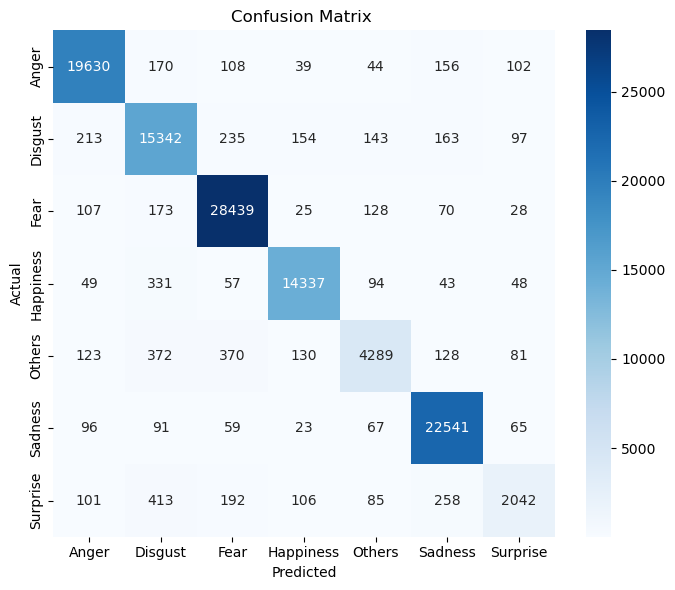

In [ ]:

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader, desc="Training", leave=True)
    for images, labels in pbar:
        images = images.to(DEVICE)
        labels = torch.tensor([label_to_idx[l] for l in labels]).to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        #  Live update in progress bar
        live_acc = 100 * correct / total
        pbar.set_postfix({
            "Loss": f"{running_loss / (total / len(labels)):.4f}",
            "Acc": f"{live_acc:.2f}%"
        })

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc


def validate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    y_true, y_pred = [], []

    pbar = tqdm(loader, desc="Validating", leave=True)
    with torch.no_grad():
        for images, labels in pbar:
            images = images.to(DEVICE)
            labels_idx = torch.tensor([label_to_idx[l] for l in labels]).to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels_idx)
            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels_idx).sum().item()
            total += labels_idx.size(0)

            y_true.extend(labels_idx.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

            #  Live validation accuracy update
            live_acc = 100 * correct / total
            pbar.set_postfix({
                "Loss": f"{running_loss / (total / len(labels_idx)):.4f}",
                "Acc": f"{live_acc:.2f}%"
            })

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    f1 = f1_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    return epoch_loss, epoch_acc, f1, recall, y_true, y_pred

# LABEL ENCODING
label_to_idx = {label: idx for idx, label in enumerate(sorted(df['label'].unique()))}
idx_to_label = {v: k for k, v in label_to_idx.items()}
print("Label mapping:", label_to_idx)

early_stopping = EarlyStopping(patience=4, min_delta=0.001)
best_acc = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, val_f1, val_recall, y_true, y_pred = validate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%, "
          f"F1: {val_f1:.3f}, Recall: {val_recall:.3f}")

    # Step scheduler
    scheduler.step(val_acc)

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_mfe_model.pth")
        print(" Model saved (best so far)")

    # Check early stopping
    early_stopping(val_acc)
    if early_stopping.early_stop:
        print("\n Early stopping triggered!")
        break


#  Plot confusion matrix each epoch
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=[idx_to_label[i] for i in range(len(idx_to_label))],
            yticklabels=[idx_to_label[i] for i in range(len(idx_to_label))])
plt.title(f"Confusion Matrix ")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


## Classification report

In [14]:
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=[idx_to_label[i] for i in range(len(idx_to_label))]))


Classification Report:

              precision    recall  f1-score   support

       Anger       0.96      0.98      0.97     20249
     Disgust       0.94      0.92      0.93     16347
        Fear       0.97      0.99      0.98     28970
   Happiness       0.96      0.97      0.96     14959
      Others       0.89      0.79      0.84      5493
     Sadness       0.97      0.98      0.98     22942
    Surprise       0.81      0.68      0.74      3197

    accuracy                           0.95    112157
   macro avg       0.93      0.90      0.91    112157
weighted avg       0.95      0.95      0.95    112157



## Applyilng model `vision transformers (ViT)`

In [ ]:
model = models.vit_b_16(pretrained=True)

# ❄️ Freeze all except the last encoder layer (encoder_layer_11)
for name, param in model.named_parameters():
    if "encoder.layers.encoder_layer_11" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

num_ftrs = model.heads.head.in_features
model.heads.head = nn.Sequential(
    nn.BatchNorm1d(num_ftrs),
    nn.Dropout(0.4),
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(0.3),
    nn.Linear(512, len(df['label'].unique()))
)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-6, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)


### Training Loop


Label mapping: {'Anger': 0, 'Disgust': 1, 'Fear': 2, 'Happiness': 3, 'Others': 4, 'Sadness': 5, 'Surprise': 6}

Epoch 1/4
Validating: 100%|██████████| 1753/1753 [1:19:27<00:00,  2.72s/it, Loss=0.6973, Acc=50.74%]
Epoch [1/4] Train Loss: 1.8232, Acc: 31.91% | Val Loss: 1.5384, Acc: 50.74%, F1: 0.499, Recall: 0.507
 Model saved 

Epoch 2/4
Validating: 100%|██████████| 1753/1753 [18:33<00:00,  1.57it/s, Loss=0.6242, Acc=57.45%]
Epoch [2/4] Train Loss: 1.5547, Acc: 48.09% | Val Loss: 1.3770, Acc: 57.45%, F1: 0.569, Recall: 0.575
 Model saved 

Epoch 3/4
Validating: 100%|██████████| 1753/1753 [26:28<00:00,  1.10it/s, Loss=0.5963, Acc=60.38%]
Epoch [3/4] Train Loss: 1.4390, Acc: 54.26% | Val Loss: 1.3156, Acc: 60.38%, F1: 0.598, Recall: 0.604
 Model saved 

Epoch 4/4
Validating: 100%|██████████| 1753/1753 [1:32:52<00:00,  3.18s/it, Loss=0.5456, Acc=66.08%]
Epoch [4/4] Train Loss: 1.3467, Acc: 58.84% | Val Loss: 1.2037, Acc: 66.08%, F1: 0.656, Recall: 0.661
 Model saved 


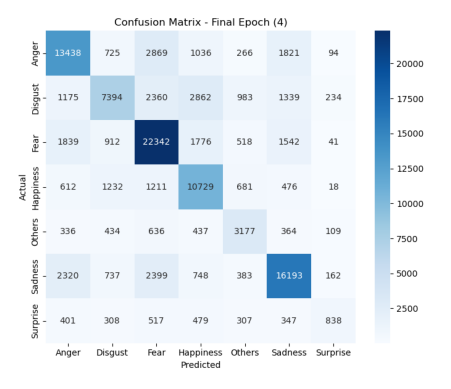

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader, desc="Training", leave=True)
    for images, labels in pbar:
        images = images.to(DEVICE)
        labels = torch.tensor([label_to_idx[l] for l in labels]).to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        live_acc = 100 * correct / total
        pbar.set_postfix({
            "Loss": f"{running_loss / (total / len(labels)):.4f}",
            "Acc": f"{live_acc:.2f}%"
        })

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc



# Validation Function

def validate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    y_true, y_pred = [], []

    pbar = tqdm(loader, desc="Validating", leave=True)
    with torch.no_grad():
        for images, labels in pbar:
            images = images.to(DEVICE)
            labels_idx = torch.tensor([label_to_idx[l] for l in labels]).to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels_idx)
            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels_idx).sum().item()
            total += labels_idx.size(0)

            y_true.extend(labels_idx.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

            live_acc = 100 * correct / total
            pbar.set_postfix({
                "Loss": f"{running_loss / (total / len(labels_idx)):.4f}",
                "Acc": f"{live_acc:.2f}%"
            })

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    f1 = f1_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    return epoch_loss, epoch_acc, f1, recall, y_true, y_pred



# Label Encoding

label_to_idx = {label: idx for idx, label in enumerate(sorted(df['label'].unique()))}
idx_to_label = {v: k for k, v in label_to_idx.items()}
print("Label mapping:", label_to_idx)
early_stopping = EarlyStopping(patience=4, min_delta=0.001)
best_acc = 0
results = []

SAVE_RESULTS_PATH = "training_results.json"
SAVE_SUMMARY_CSV = "training_summary.csv"

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    #  Training 
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)

    #  Validation
    val_loss, val_acc, val_f1, val_recall, y_true, y_pred = validate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%, "
          f"F1: {val_f1:.3f}, Recall: {val_recall:.3f}")

    # LR Scheduler 
    scheduler.step(val_acc)

    # Save Best Model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_mfe_vit_model.pth")
        print(" Model saved ")

    #  Early Stopping
    early_stopping(val_acc)
    if early_stopping.early_stop:
        print("\n Early stopping triggered!")
        break
        #  Plot confusion matrix each epoch
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=[idx_to_label[i] for i in range(len(idx_to_label))],
            yticklabels=[idx_to_label[i] for i in range(len(idx_to_label))])
plt.title(f"Confusion Matrix - Epoch {epoch+1}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=[idx_to_label[i] for i in range(len(idx_to_label))]))

 
      Classification report
      precision    recall  f1-score   support

       Anger       0.67      0.66      0.67     20249
     Disgust       0.63      0.45      0.53     16347
        Fear       0.69      0.77      0.73     28970
   Happiness       0.59      0.72      0.65     14959
      Others       0.50      0.58      0.54      5493
     Sadness       0.73      0.71      0.72     22942
    Surprise       0.56      0.26      0.36      3197

    accuracy                           0.66    112157
   macro avg       0.63      0.59      0.60    112157
weighted avg       0.66      0.66      0.66    112157


## Applying model `densenet121`

In [12]:

model = models.densenet121(pretrained=True)

#  Freeze all layers except the last dense block and classifier
for name, param in model.named_parameters():
    if "denseblock4" in name or "norm5" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

#  CLASSIFIER
num_ftrs = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.BatchNorm1d(num_ftrs),
    nn.Dropout(0.1),
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.Dropout(0.1),
    nn.Linear(256, len(df['label'].unique()))
)

model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=5)


Label mapping: {'Anger': 0, 'Disgust': 1, 'Fear': 2, 'Happiness': 3, 'Others': 4, 'Sadness': 5, 'Surprise': 6}

Epoch 1/4


Validating: 100%|██████████| 1753/1753 [1:00:47<00:00,  2.08s/it, Loss=0.2190, Acc=85.04%]


Epoch [1/4] Train Loss: 0.9131, Acc: 69.60% | Val Loss: 0.4832, Acc: 85.04%, F1: 0.847, Recall: 0.850
✅ Model saved (best so far)

Epoch 2/4


Validating: 100%|██████████| 1753/1753 [1:00:09<00:00,  2.06s/it, Loss=0.2197, Acc=85.04%]


Epoch [2/4] Train Loss: 0.5145, Acc: 83.59% | Val Loss: 0.4847, Acc: 85.04%, F1: 0.847, Recall: 0.850
✅ Model saved (best so far)

Epoch 3/4


Validating: 100%|██████████| 1753/1753 [1:00:13<00:00,  2.06s/it, Loss=0.2187, Acc=85.12%]


Epoch [3/4] Train Loss: 0.5152, Acc: 83.50% | Val Loss: 0.4824, Acc: 85.12%, F1: 0.848, Recall: 0.851
✅ Model saved (best so far)

Epoch 4/4


Validating: 100%|██████████| 1753/1753 [1:01:03<00:00,  2.09s/it, Loss=0.2193, Acc=84.94%]


Epoch [4/4] Train Loss: 0.5140, Acc: 83.70% | Val Loss: 0.4838, Acc: 84.94%, F1: 0.846, Recall: 0.849


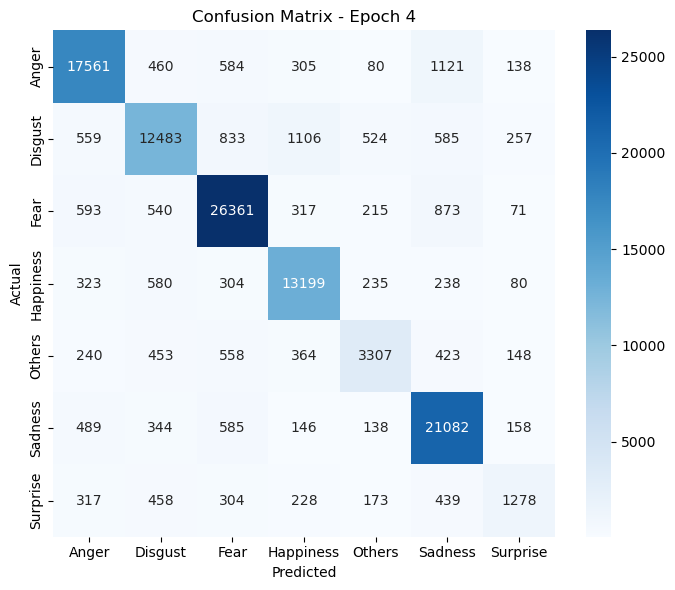

In [ ]:

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader, desc="Training", leave=True)
    for images, labels in pbar:
        images = images.to(DEVICE)
        labels = torch.tensor([label_to_idx[l] for l in labels]).to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        #  Live update in progress bar
        live_acc = 100 * correct / total
        pbar.set_postfix({
            "Loss": f"{running_loss / (total / len(labels)):.4f}",
            "Acc": f"{live_acc:.2f}%"
        })

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc


def validate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    y_true, y_pred = [], []

    pbar = tqdm(loader, desc="Validating", leave=True)
    with torch.no_grad():
        for images, labels in pbar:
            images = images.to(DEVICE)
            labels_idx = torch.tensor([label_to_idx[l] for l in labels]).to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels_idx)
            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels_idx).sum().item()
            total += labels_idx.size(0)

            y_true.extend(labels_idx.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

            #  Live validation accuracy update
            live_acc = 100 * correct / total
            pbar.set_postfix({
                "Loss": f"{running_loss / (total / len(labels_idx)):.4f}",
                "Acc": f"{live_acc:.2f}%"
            })

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    f1 = f1_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    return epoch_loss, epoch_acc, f1, recall, y_true, y_pred

# LABEL ENCODING
label_to_idx = {label: idx for idx, label in enumerate(sorted(df['label'].unique()))}
idx_to_label = {v: k for k, v in label_to_idx.items()}
print("Label mapping:", label_to_idx)

early_stopping = EarlyStopping(patience=4, min_delta=0.001)
best_acc = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, val_f1, val_recall, y_true, y_pred = validate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%, "
          f"F1: {val_f1:.3f}, Recall: {val_recall:.3f}")

    # Step scheduler
    scheduler.step(val_acc)

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_mfe_densenet121_model.pth")
        print(" Model saved (best so far)")

    # Check early stopping
    early_stopping(val_acc)
    if early_stopping.early_stop:
        print("\ Early stopping triggered!")
        break


    #  Plot confusion matrix each epoch
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=[idx_to_label[i] for i in range(len(idx_to_label))],
            yticklabels=[idx_to_label[i] for i in range(len(idx_to_label))])
plt.title(f"Confusion Matrix - Epoch {epoch+1}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [16]:
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=[idx_to_label[i] for i in range(len(idx_to_label))]))


Classification Report:

              precision    recall  f1-score   support

       Anger       0.87      0.87      0.87     20249
     Disgust       0.81      0.76      0.79     16347
        Fear       0.89      0.91      0.90     28970
   Happiness       0.84      0.88      0.86     14959
      Others       0.71      0.60      0.65      5493
     Sadness       0.85      0.92      0.88     22942
    Surprise       0.60      0.40      0.48      3197

    accuracy                           0.85    112157
   macro avg       0.80      0.76      0.78    112157
weighted avg       0.85      0.85      0.85    112157



## Applying `swin transformers` model

In [ ]:
from torch.optim.lr_scheduler import CosineAnnealingLR

num_classes = len(df['label'].unique())

# MODEL (Swin Transformer) 
# Choose variant: swin_t (tiny), swin_s (small), swin_b (base)
model = models.swin_t(weights="IMAGENET1K_V1")  # pretrained Swin Tiny

#  PARTIAL UNFREEZE (last 2 stages + head)
for name, param in model.named_parameters():
    if any(x in name for x in ["layers.2", "layers.3", "norm", "head"]):
        param.requires_grad = True
    else:
        param.requires_grad = False

# CLASSIFIER 
num_ftrs = model.head.in_features
model.head = nn.Sequential(
    nn.BatchNorm1d(num_ftrs),
    nn.Dropout(0.2),             # slightly more regularization
    nn.Linear(num_ftrs, 512),    # larger head to learn better
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(0.2),
    nn.Linear(512, num_classes)
)

model = model.to(DEVICE)

#  LOSS, OPTIMIZER, SCHEDULER 
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=5)

Label mapping: {'Anger': 0, 'Disgust': 1, 'Fear': 2, 'Happiness': 3, 'Others': 4, 'Sadness': 5, 'Surprise': 6}

Epoch 1/4


Training:   0%|          | 0/7010 [00:00<?, ?it/s]

Validating: 100%|██████████| 1753/1753 [1:00:24<00:00,  2.07s/it, Loss=0.2711, Acc=79.49%]


Epoch [1/4] Train Loss: 0.9434, Acc: 65.80% | Val Loss: 0.5981, Acc: 79.49%, F1: 0.792, Recall: 0.795
✅ Model saved (best so far)

Epoch 2/4


Validating: 100%|██████████| 1753/1753 [1:00:36<00:00,  2.07s/it, Loss=0.2394, Acc=82.03%]


Epoch [2/4] Train Loss: 0.7888, Acc: 72.00% | Val Loss: 0.5282, Acc: 82.03%, F1: 0.819, Recall: 0.820
✅ Model saved (best so far)

Epoch 3/4


Validating: 100%|██████████| 1753/1753 [1:02:18<00:00,  2.13s/it, Loss=0.1841, Acc=86.55%]


Epoch [3/4] Train Loss: 0.7029, Acc: 75.33% | Val Loss: 0.4063, Acc: 86.55%, F1: 0.863, Recall: 0.866
✅ Model saved (best so far)

Epoch 4/4


Validating: 100%|██████████| 1753/1753 [1:03:07<00:00,  2.16s/it, Loss=0.1447, Acc=89.81%]


Epoch [4/4] Train Loss: 0.5942, Acc: 79.48% | Val Loss: 0.3191, Acc: 89.81%, F1: 0.896, Recall: 0.898
✅ Model saved (best so far)


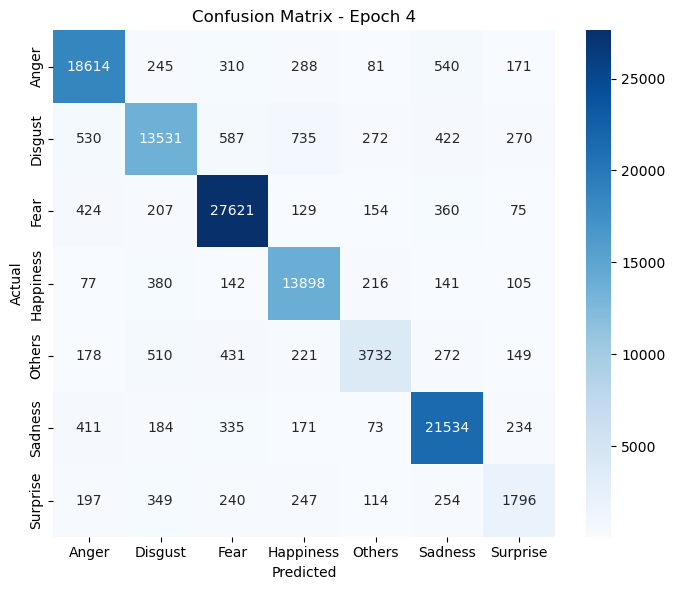

In [ ]:

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader, desc="Training", leave=True)
    for images, labels in pbar:
        images = images.to(DEVICE)
        labels = torch.tensor([label_to_idx[l] for l in labels]).to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        #  Live update in progress bar
        live_acc = 100 * correct / total
        pbar.set_postfix({
            "Loss": f"{running_loss / (total / len(labels)):.4f}",
            "Acc": f"{live_acc:.2f}%"
        })

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc


def validate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    y_true, y_pred = [], []

    pbar = tqdm(loader, desc="Validating", leave=True)
    with torch.no_grad():
        for images, labels in pbar:
            images = images.to(DEVICE)
            labels_idx = torch.tensor([label_to_idx[l] for l in labels]).to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels_idx)
            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels_idx).sum().item()
            total += labels_idx.size(0)

            y_true.extend(labels_idx.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

            #  Live validation accuracy update
            live_acc = 100 * correct / total
            pbar.set_postfix({
                "Loss": f"{running_loss / (total / len(labels_idx)):.4f}",
                "Acc": f"{live_acc:.2f}%"
            })

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    f1 = f1_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    return epoch_loss, epoch_acc, f1, recall, y_true, y_pred

# LABEL ENCODING
label_to_idx = {label: idx for idx, label in enumerate(sorted(df['label'].unique()))}
idx_to_label = {v: k for k, v in label_to_idx.items()}
print("Label mapping:", label_to_idx)

early_stopping = EarlyStopping(patience=4, min_delta=0.001)
best_acc = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, val_f1, val_recall, y_true, y_pred = validate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%, "
          f"F1: {val_f1:.3f}, Recall: {val_recall:.3f}")

    # Step scheduler
    scheduler.step(val_acc)

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_mfe_swin_model.pth")
        print(" Model saved (best so far)")

    # Check early stopping
    early_stopping(val_acc)
    if early_stopping.early_stop:
        print("\ Early stopping triggered!")
        break


    #  Plot confusion matrix each epoch
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=[idx_to_label[i] for i in range(len(idx_to_label))],
            yticklabels=[idx_to_label[i] for i in range(len(idx_to_label))])
plt.title(f"Confusion Matrix - Epoch {epoch+1}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [17]:
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=[idx_to_label[i] for i in range(len(idx_to_label))]))


Classification Report:

              precision    recall  f1-score   support

       Anger       0.91      0.92      0.92     20249
     Disgust       0.88      0.83      0.85     16347
        Fear       0.93      0.95      0.94     28970
   Happiness       0.89      0.93      0.91     14959
      Others       0.80      0.68      0.74      5493
     Sadness       0.92      0.94      0.93     22942
    Surprise       0.64      0.56      0.60      3197

    accuracy                           0.90    112157
   macro avg       0.85      0.83      0.84    112157
weighted avg       0.90      0.90      0.90    112157



## Performance comparison

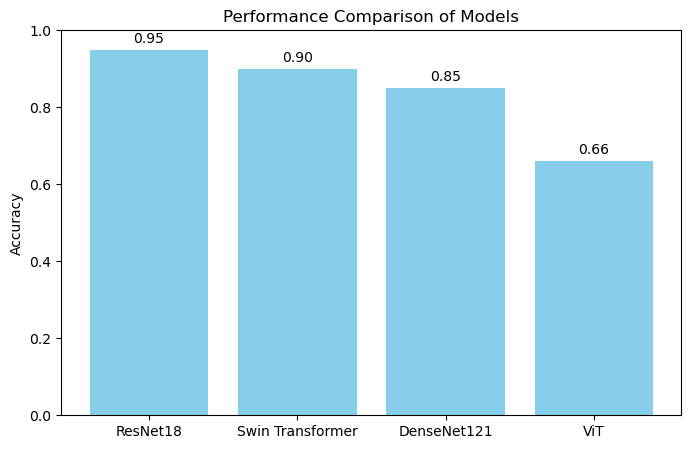

In [41]:
# Model names and accuracies
models = ['ResNet18', 'ViT', 'DenseNet121', 'Swin Transformer']
accuracy = [0.95, 0.66, 0.85, 0.90]
# Sort models by accuracy (high to low)
sorted_indices = sorted(range(len(accuracy)), key=lambda i: accuracy[i], reverse=True)
models_sorted = [models[i] for i in sorted_indices]
accuracy_sorted = [accuracy[i] for i in sorted_indices]
# Create bar plot
plt.figure(figsize=(8,5))
bars = plt.bar(models_sorted, accuracy_sorted, color=['skyblue'])
# Add accuracy values on top of each bar
for bar, acc in zip(bars, accuracy_sorted):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f"{acc:.2f}", ha='center', va='bottom', fontsize=10)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Performance Comparison of Models")
plt.show()


## Emotion Detection on test videos on multiple persons faces

In [ ]:
import os
import cv2
import torch
import torch.nn as nn
from torchvision import models, transforms
from collections import Counter
import mediapipe as mp
import csv

#  SETTINGS 
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_PATH = r"E:\micro_facial_expression\best_mfe_model.pth"  # Your trained model
VIDEO_FILE = r"D:\TestingVideo.mp4"  # Your downloaded video
OUTPUT_CSV = "test_video_emotion_results.csv"

labels = ['Anger', 'Disgust', 'Fear', 'Happiness', 'others', 'Sadness', 'Surprise']

#LOAD MODEL 
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

model = models.resnet18(pretrained=True)
for name, param in model.named_parameters():
    if "layer4" in name or "layer3" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.BatchNorm1d(num_ftrs),
    nn.Dropout(0.15),
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.Dropout(0.15),
    nn.Linear(256, len(labels))
)

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

#  MEDIAPIPE FACE DETECTOR
mp_face_detection = mp.solutions.face_detection
face_detector = mp_face_detection.FaceDetection(model_selection=1, min_detection_confidence=0.5)  # model_selection=1 for multi-face

# Colors for different faces
colors = [(0,255,0), (0,0,255), (255,0,0), (255,255,0), (0,255,255), (255,0,255)]

#  PROCESS VIDEO
def process_video(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("Error: Could not open video.")
        return Counter()

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    emotion_counts = Counter()
    frame_num = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_num += 1

        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = face_detector.process(rgb_frame)

        if results.detections:
            for idx, detection in enumerate(results.detections):
                bboxC = detection.location_data.relative_bounding_box
                h, w, _ = frame.shape
                x, y, bw, bh = int(bboxC.xmin*w), int(bboxC.ymin*h), int(bboxC.width*w), int(bboxC.height*h)
                x, y = max(0, x), max(0, y)
                bw, bh = min(w-x, bw), min(h-y, bh)
                face_img = frame[y:y+bh, x:x+bw]

                # Predict emotion
                tensor_img = transform(face_img).unsqueeze(0).to(DEVICE)
                with torch.no_grad():
                    outputs = model(tensor_img)
                    probs = torch.nn.functional.softmax(outputs, dim=1)
                    pred_idx = torch.argmax(probs, dim=1).item()
                    pred_label = labels[pred_idx]

                emotion_counts[pred_label] += 1

                # Draw bounding box and label
                color = colors[idx % len(colors)]
                cv2.rectangle(frame, (x, y), (x+bw, y+bh), color, 2)
                cv2.putText(frame, pred_label, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

        # Show frame
        cv2.imshow("Emotion Detection", frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    print(f"Total frames processed: {frame_num}")
    return emotion_counts

#RUN 
print(f"Processing video: {VIDEO_FILE}")
counts = process_video(VIDEO_FILE)
total = sum(counts.values())
percentages = {k: v/total*100 for k,v in counts.items()} if total>0 else {}

# SAVE RESULTS
with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(['Emotion', 'Count', 'Percentage'])
    for k in labels:
        writer.writerow([k, counts.get(k,0), percentages.get(k,0.0)])

print(f"\n✅ Video processed. Results saved to {OUTPUT_CSV}")
print("Emotion Counts:", counts)
print("Emotion Percentages:", percentages)


Processing video: D:\TestingVideo.mp4

✅ Video processed. Results saved to test_video_emotion_results.csv
Emotion Counts: Counter({'Happiness': 1586, 'others': 790, 'Sadness': 284, 'Surprise': 256, 'Disgust': 180, 'Fear': 151, 'Anger': 20})
Emotion Percentages: {'Surprise': 7.835935108662381, 'others': 24.181205999387817, 'Happiness': 48.54606672788491, 'Sadness': 8.69299051117233, 'Fear': 4.621977349250077, 'Anger': 0.6121824303642486, 'Disgust': 5.5096418732782375}


## detect single person emotion

In [6]:
import os
import cv2
import torch
import torch.nn as nn
from torchvision import models, transforms
from collections import Counter
import mediapipe as mp
import csv

# SETTINGS 
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_PATH = r"E:\micro_facial_expression\best_mfe_model.pth"  # Your trained model
VIDEO_FILE = r"D:\TestingVideo.mp4"  # Your downloaded video
OUTPUT_CSV = "test_video_emotion_results.csv"

labels = ['Anger', 'Disgust', 'Fear', 'Happiness', 'others', 'Sadness', 'Surprise']

#  LOAD MODEL 
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

model = models.resnet18(pretrained=True)
for name, param in model.named_parameters():
    if "layer4" in name or "layer3" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.BatchNorm1d(num_ftrs),
    nn.Dropout(0.15),
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.Dropout(0.15),
    nn.Linear(256, len(labels))
)

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

#  MEDIAPIPE FACE DETECTOR 
mp_face_detection = mp.solutions.face_detection
face_detector = mp_face_detection.FaceDetection(model_selection=0, min_detection_confidence=0.5)

#  PROCESS VIDEO
def process_video(video_path):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    emotion_counts = Counter()
    frame_num = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_num += 1

        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = face_detector.process(rgb_frame)

        if results.detections:
            for detection in results.detections:
                bboxC = detection.location_data.relative_bounding_box
                h, w, _ = frame.shape
                x, y, bw, bh = int(bboxC.xmin*w), int(bboxC.ymin*h), int(bboxC.width*w), int(bboxC.height*h)
                x, y = max(0, x), max(0, y)
                bw, bh = min(w-x, bw), min(h-y, bh)
                face_img = frame[y:y+bh, x:x+bw]

                # Predict emotion
                tensor_img = transform(face_img).unsqueeze(0).to(DEVICE)
                with torch.no_grad():
                    outputs = model(tensor_img)
                    probs = torch.nn.functional.softmax(outputs, dim=1)
                    pred_idx = torch.argmax(probs, dim=1).item()
                    pred_label = labels[pred_idx]

                emotion_counts[pred_label] += 1

                # Draw bounding box and label on frame
                cv2.rectangle(frame, (x, y), (x+bw, y+bh), (0, 255, 0), 2)
                cv2.putText(frame, pred_label, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,255,0), 2)

        # Show frame
        cv2.imshow("Emotion Detection", frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    return emotion_counts

#  RUN 
print(f"Processing video: {VIDEO_FILE}")
counts = process_video(VIDEO_FILE)
total = sum(counts.values())
percentages = {k: v/total*100 for k,v in counts.items()} if total>0 else {}

#  SAVE RESULTS 
with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(['Emotion', 'Count', 'Percentage'])
    for k in labels:
        writer.writerow([k, counts.get(k,0), percentages.get(k,0.0)])

print(f"\n✅ Video processed. Results saved to {OUTPUT_CSV}")
print("Emotion Counts:", counts)
print("Emotion Percentages:", percentages)


Processing video: D:\TestingVideo.mp4

✅ Video processed. Results saved to test_video_emotion_results.csv
Emotion Counts: Counter({'Happiness': 1018, 'others': 312, 'Disgust': 86, 'Surprise': 71, 'Fear': 54, 'Sadness': 23, 'Anger': 7})
Emotion Percentages: {'Surprise': 4.519414385741566, 'others': 19.859961807765757, 'Happiness': 64.79949077021006, 'Sadness': 1.464035646085296, 'Fear': 3.437301082113304, 'Anger': 0.4455760661998727, 'Disgust': 5.47422024188415}


 Using device: cuda
 GPU: NVIDIA GeForce RTX 3060 Ti
 Total sequences loaded: 341

Class distribution:
label
Happiness    131
Disgust       74
Anger         55
Surprise      36
Fear          21
Others        15
Sadness        9
Name: count, dtype: int64


100%|██████████| 69/69 [00:00<00:00, 4915.20it/s]



Epoch 1/20


Validation: 100%|██████████| 9/9 [00:09<00:00,  1.05s/it]


Train Loss: 1.8624
Val Loss: 1.6248 | Accuracy: 0.4783 | F1: 0.2708
New best model saved with F1: 0.2708

Epoch 2/20


...

Train Loss: 1.1084
Val Loss: 1.5642 | Accuracy: 0.4928 | F1: 0.2736

Epoch 4/20


Validation: 100%|██████████| 9/9 [00:09<00:00,  1.02s/it]


Train Loss: 0.9334
Val Loss: 1.4943 | Accuracy: 0.5217 | F1: 0.3354

Epoch 5/20


Validation: 100%|██████████| 9/9 [00:09<00:00,  1.08s/it]


Train Loss: 0.7724
Val Loss: 1.6449 | Accuracy: 0.5217 | F1: 0.3373


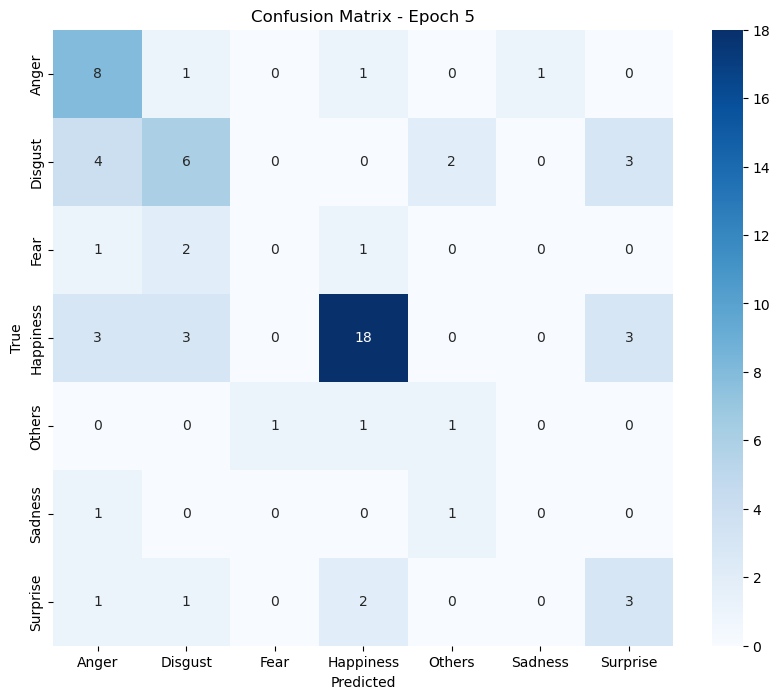


Epoch 6/20


Validation: 100%|██████████| 9/9 [00:09<00:00,  1.02s/it]


Train Loss: 0.6831
Val Loss: 1.5845 | Accuracy: 0.4783 | F1: 0.2845

Epoch 7/20


Validation: 100%|██████████| 9/9 [00:09<00:00,  1.02s/it]


Train Loss: 0.6167
Val Loss: 1.7637 | Accuracy: 0.4203 | F1: 0.2774

Epoch 8/20


...

Train Loss: 0.5899
Val Loss: 1.4255 | Accuracy: 0.5942 | F1: 0.3470
New best model saved with F1: 0.3470

Epoch 9/20


Validation: 100%|██████████| 9/9 [00:09<00:00,  1.05s/it]


Train Loss: 0.5805
Val Loss: 1.6285 | Accuracy: 0.4638 | F1: 0.2780

Epoch 10/20


Validation: 100%|██████████| 9/9 [00:09<00:00,  1.04s/it]


Train Loss: 0.5533
Val Loss: 1.5209 | Accuracy: 0.5797 | F1: 0.3269


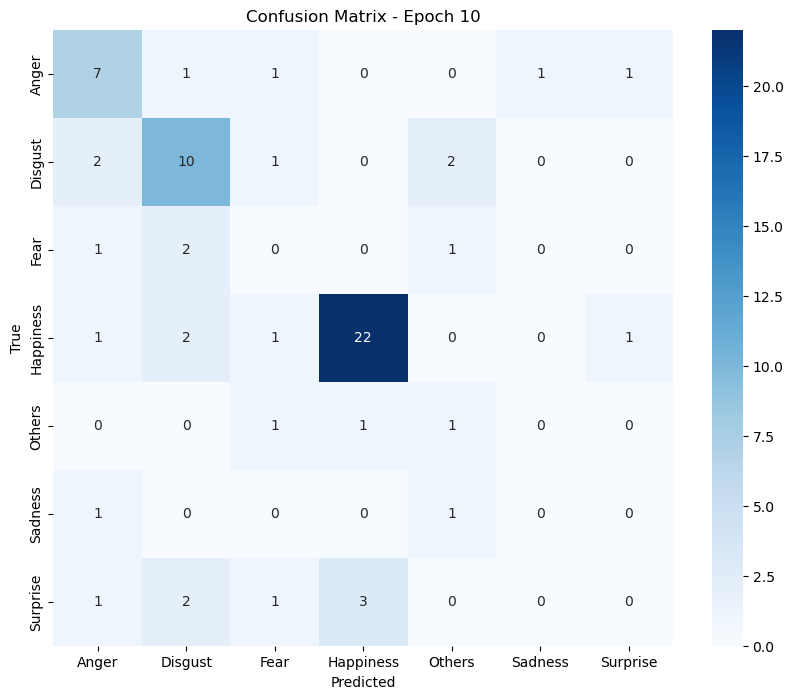


Epoch 11/20


Validation: 100%|██████████| 9/9 [00:09<00:00,  1.09s/it]


Train Loss: 0.5325
Val Loss: 1.5509 | Accuracy: 0.5362 | F1: 0.2968

Epoch 12/20


Validation: 100%|██████████| 9/9 [00:09<00:00,  1.04s/it]


Train Loss: 0.5421
Val Loss: 1.5561 | Accuracy: 0.5507 | F1: 0.2903

Epoch 13/20


...

Train Loss: 0.5067
Val Loss: 1.5187 | Accuracy: 0.5362 | F1: 0.3113

Epoch 14/20


Validation: 100%|██████████| 9/9 [00:09<00:00,  1.05s/it]


Train Loss: 0.5063
Val Loss: 1.4872 | Accuracy: 0.5797 | F1: 0.3243

Epoch 15/20


Validation: 100%|██████████| 9/9 [00:10<00:00,  1.13s/it]


Train Loss: 0.5010
Val Loss: 1.4538 | Accuracy: 0.6087 | F1: 0.3495
New best model saved with F1: 0.3495


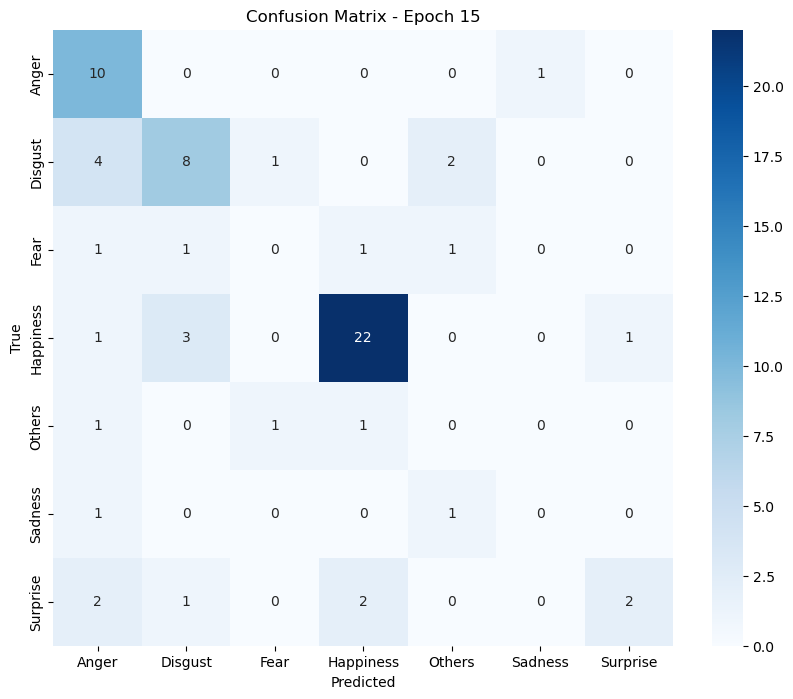


Epoch 16/20


Validation: 100%|██████████| 9/9 [00:09<00:00,  1.04s/it]


Train Loss: 0.4960
Val Loss: 1.4488 | Accuracy: 0.5507 | F1: 0.3020

Epoch 17/20


Validation: 100%|██████████| 9/9 [00:09<00:00,  1.06s/it]


Train Loss: 0.4972
Val Loss: 1.4271 | Accuracy: 0.5942 | F1: 0.3536
New best model saved with F1: 0.3536

Epoch 18/20


...

Train Loss: 0.5278
Val Loss: 1.5130 | Accuracy: 0.5797 | F1: 0.3492

Epoch 19/20


Validation: 100%|██████████| 9/9 [00:09<00:00,  1.01s/it]


Train Loss: 0.5024
Val Loss: 1.4363 | Accuracy: 0.5652 | F1: 0.3300

Epoch 20/20


Validation: 100%|██████████| 9/9 [00:09<00:00,  1.05s/it]


Train Loss: 0.5005
Val Loss: 1.4376 | Accuracy: 0.5942 | F1: 0.3542
New best model saved with F1: 0.3542


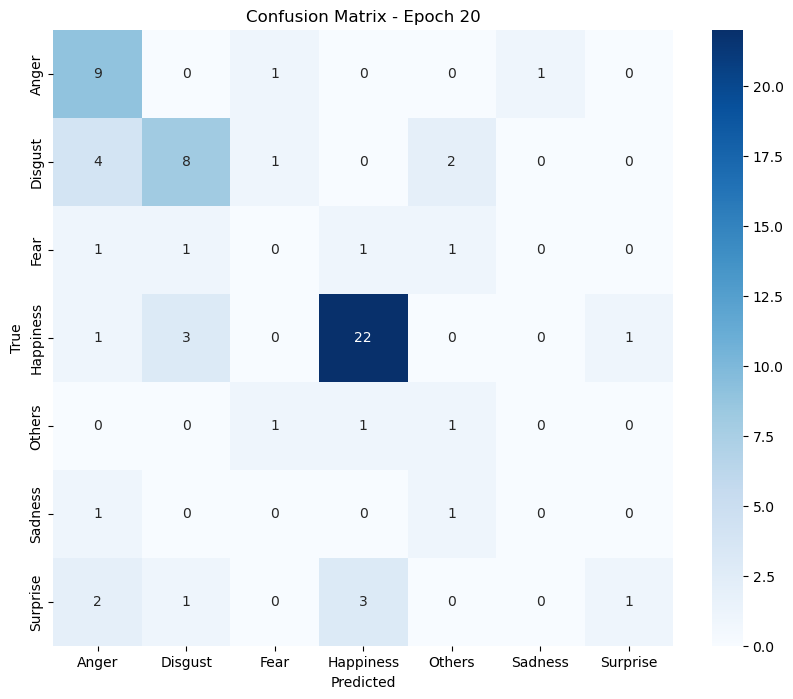

In [ ]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score, precision_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ==========================
# CONFIGURATION
# ==========================
CONFIG = {
    'base_path': r"E:\micro_facial_expression",
    'batch_size': 8,            # Reduce batch size on Windows GPU
    'epochs': 20,
    'learning_rate': 1e-4,
    'num_frames': 32,
    'img_size': 112,
    'num_workers': 0,           # Windows-safe
    'pin_memory': True,
    'seed': 42
}

# ==========================
# DEVICE SETUP
# ==========================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f" GPU: {torch.cuda.get_device_name()}")

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG['seed'])

# ==========================
# DATA PROCESSOR
# ==========================
class DataProcessor:

    @staticmethod
    def map_emotion_to_class(emotion):
        emotion = str(emotion).strip().lower()
        emotion_mapping = {
            'fear': 'Fear',
            'sad': 'Sadness', 
            'sadness': 'Sadness',
            'anger': 'Anger',
            'disgust': 'Disgust',
            'happy': 'Happiness',
            'happiness': 'Happiness',
            'surprise': 'Surprise',
            'contempt': 'Happiness'
        }
        for key, value in emotion_mapping.items():
            if key in emotion:
                return value
        return 'Others'

    @staticmethod
    def find_casme3_folder(frames_root, sub, seq, onset=None, apex=None):
        if not os.path.exists(frames_root):
            return None
        prefix = f"{sub}_{seq}".replace("__","_")
        candidates = [d for d in os.listdir(frames_root) if d.startswith(prefix) and os.path.isdir(os.path.join(frames_root,d))]
        if not candidates: return None
        onset_s = str(int(onset)) if onset not in (None, '', 'nan', np.nan) else None
        apex_s = str(int(apex)) if apex not in (None, '', 'nan', np.nan) else None
        for cand in candidates:
            suffix = cand.split('_')[-1]
            if onset_s and suffix == onset_s: return cand
            if apex_s and suffix == apex_s: return cand
        if onset_s:
            try:
                onset_val = int(onset_s)
                best_cand = min(candidates, key=lambda x: abs(int(x.split('_')[-1]) - onset_val) if x.split('_')[-1].isdigit() else float('inf'))
                return best_cand
            except: pass
        return candidates[0]

    @classmethod
    def load_all_data(cls, base_path):
        all_data = []
        # Load CASME2
        casme2_csvs = [
            os.path.join(base_path,"CASME2","CASME2_Labelling.csv"),
            os.path.join(base_path,"CASME2","CASME2","CASME2_Labelling.csv")
        ]
        for csv_path in casme2_csvs:
            if os.path.exists(csv_path):
                df = pd.read_csv(csv_path)
                for _, row in df.iterrows():
                    subj = str(row['Subject']).strip()
                    folder = str(row['Filename']).strip()
                    emotion = row.get('Estimated Emotion', row.get('EstimatedEmotion','others'))
                    label = cls.map_emotion_to_class(emotion)
                    path_options = [
                        os.path.join(base_path,"CASME2","CASME2","Extracts","cropped","cropped",subj,folder),
                        os.path.join(base_path,"CASME2","Extracts","cropped","cropped",subj,folder),
                        os.path.join(base_path,"CASME2",subj,folder)
                    ]
                    for path in path_options:
                        if os.path.exists(path):
                            all_data.append({
                                'path': path,
                                'label': label,
                                'onset': row.get('OnsetFrame'),
                                'apex': row.get('ApexFrame'),
                                'offset': row.get('OffsetFrame'),
                                'dataset':'CASME2'
                            })
                            break
                break
        # Add CASMEII, CASME3, SAMM similar way...
        # For brevity, reuse your previous code logic
        # ... You can copy the CASMEII/CASME3/SAMM logic here

        # Filter valid paths
        valid_data = []
        for item in all_data:
            if os.path.exists(item['path']):
                imgs = [f for f in os.listdir(item['path']) if f.lower().endswith(('.jpg','.png','.jpeg'))]
                if imgs: valid_data.append(item)
        df = pd.DataFrame(valid_data)
        print(f" Total sequences loaded: {len(df)}")
        if len(df)>0:
            print("\nClass distribution:")
            print(df['label'].value_counts())
        else:
            raise ValueError("No valid sequences found!")
        return df

# ==========================
# DATASET
# ==========================
class MFEDataset(Dataset):
    def __init__(self, dataframe, transform=None, num_frames=16, img_size=112, label_to_idx=None):
        self.data = dataframe
        self.transform = transform
        self.num_frames = num_frames
        self.img_size = img_size
        self.label_to_idx = label_to_idx
        self.valid_indices = self._validate_samples()

    def _validate_samples(self):
        valid_indices = []
        for idx in tqdm(range(len(self.data))):
            folder = self.data.iloc[idx]['path']
            images = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.png','.jpeg'))]
            if images: valid_indices.append(idx)
        return valid_indices

    def __len__(self):
        return len(self.valid_indices)

    def _load_frame_sequence(self, folder, onset, apex, offset):
        all_images = sorted([f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.png','.jpeg'))])
        img_paths = [os.path.join(folder,f) for f in all_images]
        if onset is not None and offset is not None:
            try:
                onset, offset = int(onset)-1, int(offset)-1
                img_paths = img_paths[max(0,onset):min(len(img_paths),offset+1)]
            except: pass
        elif apex is not None:
            try:
                apex = int(apex)-1
                start = max(0,apex - self.num_frames//2)
                img_paths = img_paths[start:start+self.num_frames]
            except: pass
        return img_paths

    def _sample_frames(self, img_paths):
        if len(img_paths)==0: return []
        if len(img_paths)>self.num_frames:
            idxs = np.linspace(0,len(img_paths)-1,self.num_frames).astype(int)
            return [img_paths[i] for i in idxs]
        elif len(img_paths)<self.num_frames:
            return img_paths + [img_paths[-1]]*(self.num_frames-len(img_paths))
        else:
            return img_paths

    def _create_dummy_sequence(self):
        dummy = Image.new('RGB',(self.img_size,self.img_size),'black')
        if self.transform: dummy=self.transform(dummy)
        return [dummy]*self.num_frames

    def __getitem__(self, idx):
        row = self.data.iloc[self.valid_indices[idx]]
        folder,label,onset,apex,offset = row['path'],row['label'],row['onset'],row['apex'],row['offset']
        try:
            img_paths = self._load_frame_sequence(folder,onset,apex,offset)
            img_paths = self._sample_frames(img_paths)
            if not img_paths: raise ValueError
            frames=[]
            for p in img_paths:
                try: img=Image.open(p).convert("RGB")
                except: img=Image.new('RGB',(self.img_size,self.img_size),'black')
                if self.transform: img=self.transform(img)
                frames.append(img)
            video = torch.stack(frames,dim=1)
            return video, self.label_to_idx[label]
        except:
            frames = self._create_dummy_sequence()
            return torch.stack(frames,dim=1), self.label_to_idx[label]

# ==========================
# MODEL
# ==========================
def create_model(num_classes, device):
    model = models.video.r3d_18(pretrained=True)
    for name,param in model.named_parameters():
        if "layer1" in name or "stem" in name: param.requires_grad=False
        else: param.requires_grad=True
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_ftrs,512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.2),
        nn.Linear(512,num_classes)
    )
    return model.to(device)

# ==========================
# TRANSFORMS
# ==========================
def get_transforms(img_size=112):
    mean,std = [0.43216,0.394666,0.37645],[0.22803,0.22145,0.216989]
    train_transform = transforms.Compose([transforms.Resize((img_size,img_size)),transforms.ToTensor(),transforms.Normalize(mean,std)])
    val_transform = transforms.Compose([transforms.Resize((img_size,img_size)),transforms.ToTensor(),transforms.Normalize(mean,std)])
    return train_transform,val_transform

# ==========================
# TRAINER
# ==========================
class ModelTrainer:
    def __init__(self, model, device, config):
        self.model,self.device,self.config = model,device,config
        self.criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
        self.optimizer = optim.AdamW(model.parameters(),lr=config['learning_rate'],weight_decay=1e-4)
        self.scheduler = optim.lr_scheduler.CosineAnnealingLR(self.optimizer,T_max=config['epochs'])
        self.train_losses,self.val_losses,self.val_metrics = [],[],[]

    def train_epoch(self,train_loader):
        self.model.train()
        running_loss=0
        for videos,labels in tqdm(train_loader,desc="Training"):
            videos,labels = videos.to(self.device),labels.to(self.device)
            self.optimizer.zero_grad()
            outputs = self.model(videos)
            loss = self.criterion(outputs,labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(),1.0)
            self.optimizer.step()
            running_loss+=loss.item()
        return running_loss/len(train_loader)

    def evaluate(self,val_loader,unique_labels):
        self.model.eval()
        all_preds,all_labels=[],[]
        running_loss=0
        with torch.no_grad():
            for videos,labels in tqdm(val_loader,desc="Validation"):
                videos,labels = videos.to(self.device),labels.to(self.device)
                outputs=self.model(videos)
                loss = self.criterion(outputs,labels)
                running_loss+=loss.item()
                preds = torch.argmax(outputs,dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        metrics={
            'loss':running_loss/len(val_loader),
            'accuracy':accuracy_score(all_labels,all_preds),
            'precision':precision_score(all_labels,all_preds,average='macro',zero_division=0),
            'recall':recall_score(all_labels,all_preds,average='macro',zero_division=0),
            'f1_score':f1_score(all_labels,all_preds,average='macro',zero_division=0),
            'confusion_matrix':confusion_matrix(all_labels,all_preds,labels=range(len(unique_labels)))
        }
        return metrics

    def plot_confusion_matrix(self,cm,unique_labels,epoch):
        plt.figure(figsize=(10,8))
        sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=unique_labels,yticklabels=unique_labels)
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title(f"Confusion Matrix - Epoch {epoch}")
        plt.show()


# MAIN
def main():
    df = DataProcessor.load_all_data(CONFIG['base_path'])
    unique_labels = sorted(df['label'].unique())
    label_to_idx = {label:idx for idx,label in enumerate(unique_labels)}
    num_classes = len(unique_labels)

    train_df,val_df = train_test_split(df,test_size=0.2,stratify=df['label'],random_state=CONFIG['seed'])
    train_transform,val_transform = get_transforms(CONFIG['img_size'])
    train_dataset = MFEDataset(train_df,train_transform,CONFIG['num_frames'],CONFIG['img_size'],label_to_idx)
    val_dataset = MFEDataset(val_df,val_transform,CONFIG['num_frames'],CONFIG['img_size'],label_to_idx)

    train_loader = DataLoader(train_dataset,batch_size=CONFIG['batch_size'],shuffle=True,num_workers=CONFIG['num_workers'],pin_memory=CONFIG['pin_memory'])
    val_loader = DataLoader(val_dataset,batch_size=CONFIG['batch_size'],shuffle=False,num_workers=CONFIG['num_workers'],pin_memory=CONFIG['pin_memory'])

    model = create_model(num_classes,DEVICE)
    trainer = ModelTrainer(model,DEVICE,CONFIG)

    best_f1=0.0
    for epoch in range(CONFIG['epochs']):
        print(f"\nEpoch {epoch+1}/{CONFIG['epochs']}")
        train_loss = trainer.train_epoch(train_loader)
        val_metrics = trainer.evaluate(val_loader,unique_labels)
        trainer.scheduler.step()

        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Loss: {val_metrics['loss']:.4f} | Accuracy: {val_metrics['accuracy']:.4f} | F1: {val_metrics['f1_score']:.4f}")

        if val_metrics['f1_score']>best_f1:
            best_f1 = val_metrics['f1_score']
            torch.save({
                'epoch':epoch,
                'model_state_dict':model.state_dict(),
                'optimizer_state_dict':trainer.optimizer.state_dict(),
                'label_to_idx':label_to_idx,
                'config':CONFIG
            },'best_model.pth')
            print(f"New best model saved with F1: {best_f1:.4f}")

        if (epoch+1)%5==0:
            trainer.plot_confusion_matrix(val_metrics['confusion_matrix'],unique_labels,epoch+1)

if __name__=="__main__":
    main()
